# Data Preprocessing and Initial Model Development
## Environment setup


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Locate this project's root whether VS Code starts in notebooks/ or the root.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/config.py").is_file()
             and (p / "data/PhiUSIIL_Phishing_URL_Dataset.csv").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook within the project containing src/ and data/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src import config as C
from src.data import load_data
from src.splits import make_split, get_xy
from src.models import build_models
print("Project:", ROOT)

from src.notebook_analysis import (load_and_summarize, plot_distributions, prepare_split,
    quality_diagnostics, review_saved_metrics, phishing_summary, train_initial_model)


Project: C:\Users\alber\Groupe_Project_1_phdai_732_gp_phiusil


## 1. Introduction & Problem Framing
### Classification objective

**Observations:**

- The task is phishing URL classification.
- Label 0 denotes phishing; label 1 denotes legitimate.
- URL-only predictors support screening before retrieving page content.


In [2]:
# Inspect the target, feature configurations, and experiment settings.
print("Target:", C.LABEL)
print("Classes:", {0: "Phishing", 1: "Legitimate"})
display(pd.DataFrame([
    {"feature_set": name, "predictors": len(columns)}
    for name, columns in C.FEATURE_SETS.items()
]))
print("Seed:", C.SEED, "| Test fraction:", C.TEST_SIZE)


Target: label
Classes: {0: 'Phishing', 1: 'Legitimate'}


,feature_set,predictors
0,full,50
1,no_derived,44
2,url_only,18


Seed: 42 | Test fraction: 0.25


## 2. Dataset Exploration & Preprocessing
### Load and validate the dataset


In [3]:
df, cleaning_log = load_and_summarize()


,Value
rows_raw,235795
cols_raw,56
duplicate_urls_removed,425
rows_clean,235370
n_unique_domains,220086
fingerprint_matches,True


,count,mean,std,min,25%,50%,75%,max
URLLength,235370.0,34.545516,41.332730,13.0,23.000,27.000,34.000,6097.000
DomainLength,235370.0,21.456022,9.127733,4.0,16.000,20.000,24.000,110.000
IsDomainIP,235370.0,0.002702,0.051912,0.0,0.000,0.000,0.000,1.000
TLDLength,235370.0,2.764269,0.599667,2.0,2.000,3.000,3.000,13.000
NoOfSubDomain,235370.0,1.164957,0.600695,0.0,1.000,1.000,1.000,10.000
HasObfuscation,235370.0,0.002052,0.045254,0.0,0.000,0.000,0.000,1.000
NoOfObfuscatedChar,235370.0,0.024880,1.877922,0.0,0.000,0.000,0.000,447.000
ObfuscationRatio,235370.0,0.000138,0.003818,0.0,0.000,0.000,0.000,0.348
NoOfLettersInURL,235370.0,19.405600,29.099537,0.0,10.000,14.000,20.000,5191.000
LetterRatioInURL,235370.0,0.515749,0.123234,0.0,0.435,0.519,0.594,0.926


Missing values: {}


### Class distribution and URL length


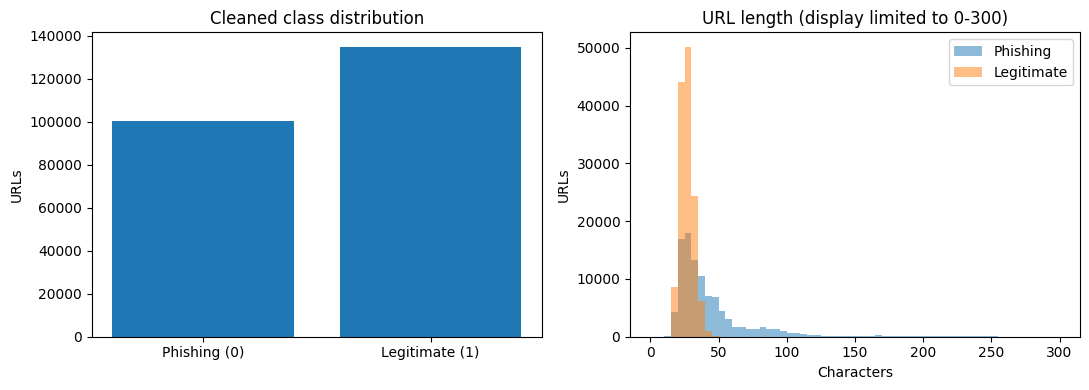

In [4]:
plot_distributions(df)


### Reuse the frozen train/test split


In [5]:
assignment, X_train, X_test, y_train, y_test = prepare_split(df)


Training: 176,527; testing: 58,843
URL-only predictors: 18
Recorded domains shared across partitions: 2318


**Observations:**

- The row-level split shares 2,318 recorded domains across training and testing.
- Domain-grouped evaluation is needed before claiming performance on unseen domains.


### Check data quality and training distributions


In [6]:
quality_diagnostics(df, assignment)


,dtype,missing,unique_train,non_finite
URLLength,int64,0,456,0
DomainLength,int64,0,100,0
IsDomainIP,int64,0,2,0
TLDLength,int64,0,11,0
NoOfSubDomain,int64,0,10,0
HasObfuscation,int64,0,2,0
NoOfObfuscatedChar,int64,0,20,0
ObfuscationRatio,float64,0,134,0
NoOfLettersInURL,int64,0,396,0
LetterRatioInURL,float64,0,695,0


,count,mean,std,min,1%,50%,95%,99%,max
URLLength,176527.0,34.599217,41.048668,13.000000,17.000000,27.000000,74.000000,146.740000,5.794000e+03
DomainLength,176527.0,21.450911,9.133470,4.000000,8.000000,20.000000,38.000000,57.000000,1.100000e+02
IsDomainIP,176527.0,0.002730,0.052183,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
TLDLength,176527.0,2.764790,0.599894,2.000000,2.000000,3.000000,3.000000,4.000000,1.300000e+01
NoOfSubDomain,176527.0,1.164456,0.600648,0.000000,0.000000,1.000000,2.000000,3.000000,1.000000e+01
HasObfuscation,176527.0,0.002090,0.045672,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
NoOfObfuscatedChar,176527.0,0.028653,2.156206,0.000000,0.000000,0.000000,0.000000,0.000000,4.470000e+02
ObfuscationRatio,176527.0,0.000148,0.004044,0.000000,0.000000,0.000000,0.000000,0.000000,3.480000e-01
NoOfLettersInURL,176527.0,19.434579,27.483009,0.000000,4.000000,14.000000,50.000000,100.000000,4.992000e+03
LetterRatioInURL,176527.0,0.515798,0.123366,0.000000,0.231000,0.519000,0.731000,0.786000,9.260000e-01


label,phishing_share,legitimate_share
split,,
test,0.427069,0.572931
train,0.427073,0.572927


Constant training predictors: []


### Execute cleaning, feature preparation, and scaling checks


In [7]:
from src.preprocessing import run_preprocessing, show_preprocessing_results

# Shared loader, original row identities, existing split, and training-only scaling.
# Save cleaned data and preprocessing diagnostics using the project module.
preprocessing_summary = run_preprocessing()
preprocessing_results = show_preprocessing_results()


,Verified result
rows_raw,235795
rows_clean,235370
duplicate_urls_removed,425
missing_values,0
non_finite_model_values,0
fingerprint_matches,True


,feature_set,n_features,n_train,n_test,scaled_inputs_finite
0,full,50,176527,58843,True
1,no_derived,44,176527,58843,True
2,url_only,18,176527,58843,True


,split,phishing,legitimate
0,test,25130,33713
1,train,75390,101137


Cleaned dataset: data\PhiUSIIL_cleaned.csv
Fitted on training rows only; model pipelines refit within each CV fold.


**Observations:**

- Cleaning removes 425 duplicate URLs and retains 235,370 rows.
- No missing or non-finite model values were found.
- Numeric feature sets contain 50, 44, and 18 predictors.
- Scaling is fitted on training rows; logistic-regression pipelines refit it within cross-validation.
- Imputation and categorical encoding are not needed for the configured inputs.
- Outliers are retained.


## 3. Initial Model Development
### Define the model roster


In [8]:
# 3. Initial Model Development
# Use the project's shared model roster, feature sets, and frozen split.
from src import config as C
from src.models import build_models
from src.initial_models import run_initial_models, show_initial_results
from src.notebook_analysis import review_saved_metrics, phishing_summary

models = build_models()
display(models)
print("Feature sets:", {name: len(columns) for name, columns in C.FEATURE_SETS.items()})
print("Seed:", C.SEED, "| Cross-validation folds:", C.CV_FOLDS)
print("Frozen split:", C.SPLIT_FILE)


{'baseline_majority': DummyClassifier(strategy='most_frequent'),
 'logistic_regression': Pipeline(steps=[('scale', StandardScaler()),
                 ('clf', LogisticRegression(max_iter=2000, random_state=42))]),
 'decision_tree': DecisionTreeClassifier(random_state=42),
 'random_forest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)}

Feature sets: {'full': 50, 'no_derived': 44, 'url_only': 18}
Seed: 42 | Cross-validation folds: 5
Frozen split: C:\Users\alber\Groupe_Project_1_phdai_732_gp_phiusil\results\split_assignment.csv


### Train and evaluate all feature configurations


In [9]:
# Fit all four models across all three feature sets using evaluate().
# The completed run is already saved. Set True to repeat training and CV.
# The runner archives prior metrics and never regenerates the split.
RUN_TRAINING = False
if RUN_TRAINING:
    trained_records = run_initial_models()
else:
    print("Using the completed training run. Set RUN_TRAINING=True to retrain all 12 configurations.")


Using the completed training run. Set RUN_TRAINING=True to retrain all 12 configurations.


**Observations:**

- All twelve configurations have already been trained.
- `RUN_TRAINING = False` reuses that completed run; set it to `True` to repeat fitting and five-fold cross-validation through the shared runner.


### Compare held-out results and confusion matrices


,feature_set,model,accuracy,phishing_precision,phishing_recall,phishing_f1,roc_auc,cv_f1_mean
0,full,baseline_majority,0.572931,0.000000,0.000000,0.000000,0.500000,NaN
1,full,logistic_regression,0.999932,1.000000,0.999841,0.999920,1.000000,0.999876
2,full,decision_tree,1.000000,1.000000,1.000000,1.000000,1.000000,0.999995
3,full,random_forest,1.000000,1.000000,1.000000,1.000000,1.000000,0.999995
4,no_derived,baseline_majority,0.572931,0.000000,0.000000,0.000000,0.500000,NaN
5,no_derived,logistic_regression,0.999252,0.999522,0.998727,0.999124,0.999994,0.999362
6,no_derived,decision_tree,0.998997,0.998370,0.999284,0.998827,0.999034,0.999056
7,no_derived,random_forest,0.999864,0.999920,0.999761,0.999841,1.000000,0.999876
8,url_only,baseline_majority,0.572931,0.000000,0.000000,0.000000,0.500000,NaN
9,url_only,logistic_regression,0.995887,0.999599,0.990768,0.995164,0.998135,0.996629


CV F1 uses legitimate (1); phishing metrics use phishing (0).
Completed: 2026-09-15T20:15:31.553986+00:00


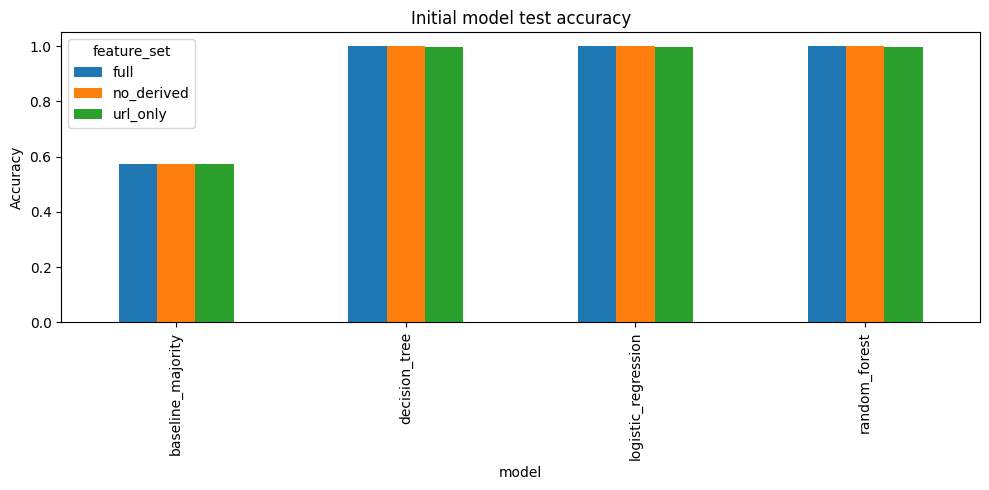

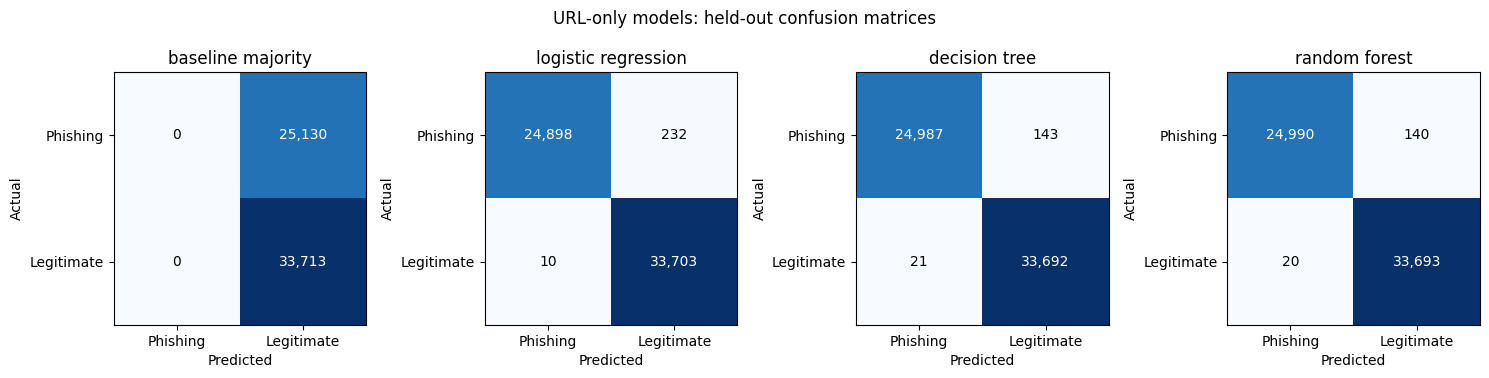

In [10]:
# Validate and display the completed comparison; save accuracy and confusion-matrix plots.
initial_results = show_initial_results()


### Evaluate phishing-class performance


In [11]:
# Inspect the canonical metric files and persist phishing-oriented metrics.
records = review_saved_metrics()
phishing_summary(records)


,feature_set,model,n_features,accuracy,precision,recall,f1,roc_auc
0,full,baseline_majority,50,0.572931,0.572931,1.000000,0.728489,0.500000
1,full,decision_tree,50,1.000000,1.000000,1.000000,1.000000,1.000000
2,full,logistic_regression,50,0.999932,0.999881,1.000000,0.999941,1.000000
3,full,random_forest,50,1.000000,1.000000,1.000000,1.000000,1.000000
4,no_derived,baseline_majority,44,0.572931,0.572931,1.000000,0.728489,0.500000
5,no_derived,decision_tree,44,0.998997,0.999466,0.998784,0.999125,0.999034
6,no_derived,logistic_regression,44,0.999252,0.999051,0.999644,0.999348,0.999994
7,no_derived,random_forest,44,0.999864,0.999822,0.999941,0.999881,1.000000
8,url_only,baseline_majority,18,0.572931,0.572931,1.000000,0.728489,0.500000
9,url_only,decision_tree,18,0.997213,0.995774,0.999377,0.997572,0.996727


Saved precision, recall, and F1 use legitimate (1) as positive.
Phishing precision: 99.92%
Phishing recall: 99.44%


,features,model,phishing_precision,phishing_recall,phishing_f1,balanced_accuracy,missed_phishing,false_alerts
0,full,baseline_majority,0.000000,0.000000,0.000000,0.500000,25130,0
1,full,decision_tree,1.000000,1.000000,1.000000,1.000000,0,0
2,full,logistic_regression,1.000000,0.999841,0.999920,0.999920,4,0
3,full,random_forest,1.000000,1.000000,1.000000,1.000000,0,0
4,no_derived,baseline_majority,0.000000,0.000000,0.000000,0.500000,25130,0
5,no_derived,decision_tree,0.998370,0.999284,0.998827,0.999034,18,41
6,no_derived,logistic_regression,0.999522,0.998727,0.999124,0.999185,32,12
7,no_derived,random_forest,0.999920,0.999761,0.999841,0.999851,6,2
8,url_only,baseline_majority,0.000000,0.000000,0.000000,0.500000,25130,0
9,url_only,decision_tree,0.999160,0.994310,0.996729,0.996843,143,21


**Observations:**

- The URL-only random forest achieved 99.73% accuracy, 99.92% phishing precision, and 99.44% phishing recall: 140 phishing URLs were missed and 20 legitimate URLs were flagged.
- Full-feature accuracy reaches 100%; this motivates investigation of dataset artifacts rather than a deployment-readiness claim.
- Saved CV F1 uses legitimate as the positive class.


### Source

**Observations:**

- Dataset label definitions are documented by [Prasad and Chandra, UCI PhiUSIIL dataset](https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset).
- Numerical observations above come from the executed project artifacts.
